<a href="https://colab.research.google.com/github/Fariasgui/MVP_DataScience_2601/blob/main/MVP_ML_Analytics_20261_Guilherme_Farias_4052026000231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Guilherme Farias Alves_  
**Matrícula:** _4052026000231_  
**Data:** _30/06/2026_  
**Dataset e link da fonte:** _Pokemon- Weedle's Cave: https://www.kaggle.com/datasets/terminus7/pokemon-challenge_  
**Tipo de problema:** _Classificação_  


# 1. Definição do problema

## 1.1 Descrição do problema

As batalhas Pokémon são determinadas por diversos atributos dos personagens, como Vida, Ataque, Defesa, Velocidade e Tipagem. Embora jogadores experientes consigam estimar qual Pokémon possui vantagem em determinado confronto, este processo pode ser automatizado utilizando técnicas de Machine Learning.

Neste projeto será construída uma solução capaz de aprender padrões a partir de batalhas anteriores para prever automaticamente o vencedor de novos confrontos.





## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar um modelo de Machine Learning capaz de prever o vencedor de uma batalha entre dois Pokémons a partir de um histórico de confrontos e status dos Pokémons.

Logo, trata-se de um problema de **Classificação Supervisionada**, onde o modelo deverá prever qual dos dois monstros de bolso vencerá o confronto.


## 1.3 Tipo de problema
**Tipo escolhido:** _Classificação_  
**Justificativa:** _Pois o modelo deverá prever qual dos dois Pokémons vencerá o confronto_



## 1.4 Premissas, hipóteses e critérios de sucesso

##Hipóteses

Antes de iniciar a análise, algumas hipóteses serão investigadas:

1. Pokémon mais rápidos tendem a vencer mais batalhas.
2. Atributos ofensivos possuem maior influência nas batalhas do que atributos defensivos.
3. Pokémon lendários possuem maior taxa de vitória.
4. A diferença entre os atributos dos dois Pokémon é mais relevante do que os valores absolutos.
5. O primeiro Pokémon listado na batalha pode possuir vantagem estratégica.
6. Os tipos dos Pokémons influênciam nas batalhas.

Estas hipóteses serão analisadas por meio de estatísticas descritivas, visualizações gráficas e da importância das variáveis identificadas pelos modelos treinados.

##Métricas de Avaliação

Por se tratar de um problema de classificação binária, serão utilizadas as seguintes métricas:

- **Accuracy** (principal métrica): percentual de batalhas corretamente classificadas.
- **Precision**: proporção de previsões positivas corretas.
- **Recall**: capacidade do modelo em identificar corretamente os vencedores.
- **F1-Score**: média harmônica entre Precision e Recall.
- **Matriz de Confusão**: análise qualitativa dos acertos e erros do modelo.

Embora diversas métricas sejam analisadas, a **Accuracy** será utilizada como principal indicador para comparação entre os modelos, uma vez que a base de dados apresenta distribuição relativamente equilibrada entre as classes.

## Resultado Mínimo Esperado

Considera-se que o MVP será bem-sucedido caso:

- apresente desempenho superior ao modelo baseline (Dummy Classifier);
- alcance uma acurácia mínima de **90%** no conjunto de teste;
- produza resultados consistentes entre treino e teste, evitando sinais evidentes de overfitting;
- permita interpretar quais atributos exercem maior influência na previsão das batalhas.

## Restrições do MVP

Como este projeto possui caráter acadêmico, algumas limitações são assumidas:

- serão utilizados apenas os atributos disponibilizados no dataset original;
- não serão consideradas mecânicas específicas das batalhas, como golpes utilizados, habilidades especiais, itens equipados, condições climáticas ou efeitos de status;
- o modelo será treinado exclusivamente com batalhas históricas fornecidas pelo dataset;
- o foco do projeto está na construção de um pipeline completo de Machine Learning, e não necessariamente na obtenção do melhor desempenho possível em competições do Kaggle.

# 2. Ambiente, bibliotecas e reprodutibilidade


In [73]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações do ambiente
import os
import sys
import time
import random
import warnings
import kagglehub

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Definição da SEED para reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Bibliotecas de Machine Learning
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
# Avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Python:", sys.version.split()[0])
print(f"SEED definida como: {SEED}")

Python: 3.12.13
SEED definida como: 42


# 3. Seleção e carga dos dados

## 3.1 Fonte dos Dados

Para o desenvolvimento deste MVP foi utilizado o dataset **Pokémon Challenge - Weedle's Cave**, disponibilizado na plataforma Kaggle. O conjunto de dados reúne informações sobre as características dos Pokémon e um histórico de batalhas entre eles, permitindo a construção de modelos capazes de prever o vencedor de novos confrontos.

**Nome do dataset**

- Pokémon Challenge - Weedle's Cave

**Fonte**

- https://www.kaggle.com/datasets/terminus7/pokemon-challenge

O dataset é composto por três arquivos principais:

- **pokemon.csv**: contém as características de cada Pokémon, como atributos de combate, tipagem, geração e indicação se é lendário;
- **combats.csv**: contém aproximadamente 50 mil batalhas históricas, informando os dois Pokémon participantes e o vencedor do confronto;
- **tests.csv**: contém batalhas sem o resultado conhecido, destinadas à realização de previsões utilizando o modelo treinado.

## Justificativa da escolha

A escolha deste dataset foi motivada por diversos fatores.

Primeiramente, trata-se de um problema clássico de **Classificação Supervisionada Binária**, adequado aos objetivos da disciplina e ao desenvolvimento de um pipeline completo de Machine Learning.

Além disso, o dataset apresenta características que tornam o projeto mais desafiador, entre essas características destacam-se:

- necessidade de integração entre diferentes bases de dados;
- realização de engenharia de atributos (Feature Engineering);
- construção de variáveis derivadas para representar as diferenças entre os atributos dos Pokémon;
- possibilidade de comparar diferentes algoritmos de classificação;
- facilidade de interpretação dos resultados obtidos.

Outro fator considerado foi a natureza lúdica do tema, que permite apresentar conceitos de Machine Learning em um contexto de fácil compreensão, sem comprometer o rigor técnico da análise.

## Restrições e condições consideradas

Para garantir que o escopo do MVP permaneça compatível com os objetivos da disciplina, foram definidas as seguintes restrições:

- serão utilizados exclusivamente os dados disponibilizados no dataset original;
- não serão incorporadas informações externas sobre Pokémon ou mecânicas adicionais das batalhas;
- o modelo considerará apenas os atributos disponíveis antes do início do combate, não sendo utilizadas informações que só seriam conhecidas durante a batalha;
- as previsões serão realizadas apenas para confrontos individuais entre dois Pokémon.

## Aspectos éticos, privacidade e licença

O dataset é composto exclusivamente por informações públicas referentes ao universo fictício da franquia Pokémon, não contendo qualquer dado pessoal ou informação sensível.

Dessa forma, não existem riscos relacionados à privacidade, confidencialidade ou tratamento de dados pessoais, conforme os princípios estabelecidos pela Lei Geral de Proteção de Dados (LGPD).

O conjunto de dados é disponibilizado publicamente na plataforma Kaggle para fins de estudo, pesquisa e desenvolvimento de modelos de Machine Learning, sendo utilizado neste projeto exclusivamente para fins acadêmicos.


## 3.2 Carga dos dados

O conjunto de dados é obtido diretamente da plataforma Kaggle utilizando a biblioteca `kagglehub`, garantindo que o notebook seja totalmente reproduzível e independente de arquivos locais.

Após o download automático, os arquivos são carregados para DataFrames do Pandas para posterior exploração e preparação dos dados.


In [2]:
path = kagglehub.dataset_download("terminus7/pokemon-challenge")
print("Path to dataset files:", path)

pokemon = pd.read_csv(os.path.join(path, "pokemon.csv"))
combats = pd.read_csv(os.path.join(path, "combats.csv"))
tests = pd.read_csv(os.path.join(path, "tests.csv"))

print("="*50)
print("Bases carregadas com sucesso!")
print("="*50)

100%|██████████| 285k/285k [00:00<00:00, 859kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/terminus7/pokemon-challenge/versions/1
Bases carregadas com sucesso!


### Sample das tabelas do dataset

In [3]:
pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [4]:
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [5]:
tests.head()

,First_pokemon,Second_pokemon
0,129,117
1,660,211
2,706,115
3,195,618
4,27,656


## 3.3 Visão geral do dataset

Nesta etapa serão analisadas as principais características das bases utilizadas, incluindo:

- dimensão dos datasets;
- tipos de dados de cada atributo;
- existência de valores ausentes;
- registros duplicados;
- identificação de colunas que não devem ser utilizadas diretamente no treinamento do modelo;
- descrição da variável alvo (target).

Essa análise inicial permite identificar possíveis necessidades de tratamento e auxilia na definição das próximas etapas do projeto.


In [6]:
# Dimensão das bases
print("="*60)
print("DIMENSÃO DOS DATASETS")
print("="*60)

print(f"pokemon.csv : {pokemon.shape[0]} linhas x {pokemon.shape[1]} colunas")
print(f"combats.csv : {combats.shape[0]} linhas x {combats.shape[1]} colunas")
print(f"tests.csv   : {tests.shape[0]} linhas x {tests.shape[1]} colunas")

DIMENSÃO DOS DATASETS
pokemon.csv : 800 linhas x 12 colunas
combats.csv : 50000 linhas x 3 colunas
tests.csv   : 10000 linhas x 2 colunas


In [7]:
# Tipos de dados
print("="*60)
print("TIPOS DOS ATRIBUTOS")
print("="*60)

print("Pokémons")
display(pokemon.dtypes.to_frame("Tipo"))
print("="*60)

print("Combates")
display(combats.dtypes.to_frame("Tipo"))
print("="*60)

print("Testes")
display(tests.dtypes.to_frame("Tipo"))
print("="*60)

TIPOS DOS ATRIBUTOS
Pokémons


,Tipo
#,int64
Name,object
Type 1,object
Type 2,object
HP,int64
Attack,int64
Defense,int64
Sp. Atk,int64
Sp. Def,int64
Speed,int64


Combates


,Tipo
First_pokemon,int64
Second_pokemon,int64
Winner,int64


Testes


,Tipo
First_pokemon,int64
Second_pokemon,int64


In [8]:
# Valores ausentes
print("="*60)
print("VALORES AUSENTES")
print("="*60)

print("\nPokemon")
display(pokemon.isna().sum())

print("\nCombats")
display(combats.isna().sum())

print("\nTests")
display(tests.isna().sum())


VALORES AUSENTES

Pokemon


,0
#,0
Name,1
Type 1,0
Type 2,386
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0



Combats


,0
First_pokemon,0
Second_pokemon,0
Winner,0



Tests


,0
First_pokemon,0
Second_pokemon,0


In [9]:
# Registros duplicados
print("="*60)
print("REGISTROS DUPLICADOS")
print("="*60)

print(f"pokemon.csv : {pokemon.duplicated().sum()}")
print(f"combats.csv : {combats.duplicated().sum()}")
print(f"tests.csv   : {tests.duplicated().sum()}")

REGISTROS DUPLICADOS
pokemon.csv : 0
combats.csv : 1952
tests.csv   : 70


A partir da estrutura das bases, é possível identificar algumas colunas que merecem atenção durante o desenvolvimento do modelo.

###**Colunas identificadoras (ID)**

Na base `pokemon.csv`, a coluna `#` representa o identificador único de cada Pokémon. Essa variável será utilizada apenas para realizar a integração entre as bases de dados e não deverá compor o conjunto de atributos utilizado para treinamento do modelo.

Nas bases `combats.csv` e `tests.csv`, as colunas `First_pokemon` e `Second_pokemon` também representam identificadores dos Pokémon participantes da batalha. Esses identificadores serão utilizados para relacionar as informações presentes em `pokemon.csv`.

###**Variável alvo (Target)**

A variável alvo do problema é a coluna `Winner`, presente na base `combats.csv`, que identifica qual Pokémon venceu cada batalha.

Como o objetivo do projeto é prever o vencedor de novos confrontos, essa variável será utilizada durante o treinamento do modelo.

### **Registros duplicados e valores ausentes**

A análise inicial dos datasets mostrou que a base `pokemon.csv` apresenta uma concentração significativa de valores ausentes na coluna `Type 2`. Entretanto, esses valores não representam um problema de qualidade dos dados, mas sim uma característica do próprio universo Pokémon, já que nem todos os Pokémon possuem um tipo secundário.

Dessa forma, a ausência de informação nessa coluna será interpretada como a inexistência de um segundo tipo e será tratada adequadamente durante a etapa de preparação dos dados, preservando essa característica para utilização pelo modelo.

**Em relação aos registros duplicados**, foram identificadas ocorrências apenas nas bases `combats.csv` e `tests.csv`. Esse comportamento é esperado, pois um mesmo par de Pokémon pode se enfrentar diversas vezes ao longo do histórico de batalhas, inclusive em ordens diferentes (Pokémon A × Pokémon B e Pokémon B × Pokémon A).

Assim, esses registros não são considerados duplicatas indevidas, mas sim observações válidas que representam diferentes ocorrências de batalhas e, portanto, serão mantidos para as etapas de análise e modelagem.


## 3.4 Dicionário de dados

### Base: `pokemon.csv`

Esta base contém as características individuais de cada Pokémon e será utilizada para enriquecer a base de batalhas através da integração pelo identificador (`#`).

| Variável | Descrição | Utilização no modelo |
|----------|-----------|----------------------|
| # | Identificador do Pokémon | Utilizada para realizar a integração entre as bases (Join). Não será utilizada como atributo preditor. |
| Name | Nome do Pokémon | Não será utilizada, por não agregar informação relevante ao modelo e possuir alta cardinalidade. |
| Type 1 | Tipo principal | Será utilizada como variável categórica. |
| Type 2 | Tipo secundário | Será utilizada como variável categórica, considerando a ausência de valor como inexistência de um segundo tipo. |
| HP | Pontos de vida | Será utilizada como variável numérica. |
| Attack | Ataque | Será utilizada como variável numérica. |
| Defense | Defesa | Será utilizada como variável numérica. |
| Sp. Atk | Ataque Especial | Será utilizada como variável numérica. |
| Sp. Def | Defesa Especial | Será utilizada como variável numérica. |
| Speed | Velocidade | Será utilizada como variável numérica. |
| Generation | Geração | Será utilizada como variável categórica/ordinal. |
| Legendary | Indica se o Pokémon é lendário | Será utilizada como variável categórica binária. |

---

### Base: `combats.csv`

Esta base contém o histórico de batalhas e será utilizada para treinamento do modelo supervisionado.

| Variável | Descrição | Utilização no modelo |
|----------|-----------|----------------------|
| First_pokemon | Identificador do primeiro Pokémon da batalha | Utilizada para recuperar os atributos do primeiro Pokémon na base `pokemon.csv`. |
| Second_pokemon | Identificador do segundo Pokémon da batalha | Utilizada para recuperar os atributos do segundo Pokémon na base `pokemon.csv`. |
| Winner | Identificador do Pokémon vencedor | Variável alvo (Target). Será transformada em uma variável binária após a integração dos dados, indicando se o vencedor foi o primeiro ou o segundo Pokémon da batalha. |

---

### Base: `tests.csv`

Esta base possui a mesma estrutura da base de batalhas, porém sem a variável alvo, sendo utilizada para geração das previsões finais do modelo.

| Variável | Descrição | Utilização no modelo |
|----------|-----------|----------------------|
| First_pokemon | Identificador do primeiro Pokémon | Utilizada para recuperar os atributos do primeiro Pokémon. |
| Second_pokemon | Identificador do segundo Pokémon | Utilizada para recuperar os atributos do segundo Pokémon. |

A base tests.csv poderia ser utilizada posteriormente para geração de previsões em batalhas sem vencedor conhecido. Porém, para o MVP, ela não será utilizada.


# 4. Construção da Base Analítica para Modelagem

Nesta etapa será construída a base analítica que será utilizada nas próximas fases do projeto.

As bases originais estão separadas em:

- `pokemon.csv`: contém os atributos individuais dos Pokémon;
- `combats.csv`: contém o histórico de batalhas;
- `tests.csv`: contém confrontos sem o vencedor conhecido.

Como o objetivo do projeto é prever o vencedor de uma batalha entre dois Pokémon, é necessário integrar os atributos dos dois competidores em uma única linha. Além disso, serão criadas variáveis derivadas que representem a diferença entre os atributos dos Pokémon em cada confronto.

Essa etapa é fundamental para que o modelo consiga aprender padrões relacionados à vantagem relativa de um Pokémon sobre o outro.

## 4.1 Padronização dos nomes das colunas

Antes de realizar as integrações entre as bases, os nomes das colunas serão padronizados para facilitar a manipulação dos dados e evitar problemas com espaços, pontos ou caracteres especiais.

In [10]:
# Cópia das bases originais
pokemon_base = pokemon.copy()
combats_base = combats.copy()
tests_base = tests.copy()

# Padronização dos nomes das colunas da base pokemon
pokemon_base = pokemon_base.rename(columns={
    "#": "pokemon_id",
    "Name": "name",
    "Type 1": "type_1",
    "Type 2": "type_2",
    "HP": "hp",
    "Attack": "attack",
    "Defense": "defense",
    "Sp. Atk": "sp_atk",
    "Sp. Def": "sp_def",
    "Speed": "speed",
    "Generation": "generation",
    "Legendary": "legendary"
})

# Padronização dos nomes das colunas da base de batalhas
combats_base = combats_base.rename(columns={
    "First_pokemon": "pokemon_1_id",
    "Second_pokemon": "pokemon_2_id",
    "Winner": "winner"
})

# Padronização dos nomes das colunas da base de teste
tests_base = tests_base.rename(columns={
    "First_pokemon": "pokemon_1_id",
    "Second_pokemon": "pokemon_2_id"
})

pokemon_base.head()

,pokemon_id,name,type_1,type_2,hp,attack,defense,sp_atk,sp_def,speed,generation,legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


## 4.2 Tratamento inicial da coluna `type_2`

A coluna `type_2` possui valores ausentes porque nem todos os Pokémon possuem um segundo tipo. Portanto, esses valores não representam erro ou ausência indevida de informação.

Para preservar essa característica, os valores ausentes serão substituídos por `"None"`, indicando explicitamente que o Pokémon não possui tipo secundário.

In [11]:
pokemon_base["type_2"] = pokemon_base["type_2"].fillna("None")

pokemon_base[["name", "type_1", "type_2"]].head()

,name,type_1,type_2
0,Bulbasaur,Grass,Poison
1,Ivysaur,Grass,Poison
2,Venusaur,Grass,Poison
3,Mega Venusaur,Grass,Poison
4,Charmander,Fire,None


## 4.3 Integração da base de batalhas com os atributos dos Pokémon

A base `combats_base` contém apenas os identificadores dos dois Pokémon e o vencedor da batalha. Para construir a base de modelagem, será necessário trazer os atributos do primeiro e do segundo Pokémon para cada linha da base de batalhas.

Para isso, serão realizados dois joins:

- um join para adicionar os atributos do primeiro Pokémon;
- outro join para adicionar os atributos do segundo Pokémon.

In [12]:
# Atributos que serão utilizados da base de Pokémon
pokemon_features = [
    "pokemon_id",
    "name",
    "type_1",
    "type_2",
    "hp",
    "attack",
    "defense",
    "sp_atk",
    "sp_def",
    "speed",
    "generation",
    "legendary"
]

pokemon_lookup = pokemon_base[pokemon_features].copy()

# Join para adicionar atributos do primeiro Pokémon
df_model = combats_base.merge(
    pokemon_lookup.add_suffix("_1"),
    left_on="pokemon_1_id",
    right_on="pokemon_id_1",
    how="left"
)

# Join para adicionar atributos do segundo Pokémon
df_model = df_model.merge(
    pokemon_lookup.add_suffix("_2"),
    left_on="pokemon_2_id",
    right_on="pokemon_id_2",
    how="left"
)

df_model.head()

,pokemon_1_id,pokemon_2_id,winner,pokemon_id_1,name_1,type_1_1,type_2_1,hp_1,attack_1,defense_1,...,type_1_2,type_2_2,hp_2,attack_2,defense_2,sp_atk_2,sp_def_2,speed_2,generation_2,legendary_2
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,...,Grass,Dark,70,70,40,60,40,60,3,False
1,702,701,701,702,Virizion,Grass,Fighting,91,90,72,...,Rock,Fighting,91,129,90,72,90,108,5,True
2,191,668,668,191,Togetic,Fairy,Flying,55,40,85,...,Psychic,None,75,75,75,125,95,40,5,False
3,237,683,683,237,Slugma,Fire,None,40,40,40,...,Dragon,None,77,120,90,60,90,48,5,False
4,151,231,151,151,Omastar,Rock,Water,70,60,125,...,Bug,Rock,20,10,230,10,230,5,2,False


## 4.4 Construção da variável alvo

A variável original `winner` indica o identificador do Pokémon vencedor. Para transformar o problema em uma classificação binária, será criada a variável `target`.

A regra adotada será:

- `1`: o primeiro Pokémon venceu;
- `0`: o segundo Pokémon venceu.

Essa transformação facilita a modelagem, pois o objetivo passa a ser prever se o primeiro Pokémon da batalha será ou não o vencedor.

In [13]:
df_model["target"] = np.where(
    df_model["winner"] == df_model["pokemon_1_id"],
    1,
    0
)

df_model[["pokemon_1_id", "pokemon_2_id", "winner", "target"]].head()

,pokemon_1_id,pokemon_2_id,winner,target
0,266,298,298,0
1,702,701,701,0
2,191,668,668,0
3,237,683,683,0
4,151,231,151,1


In [14]:
# Distribuição inicial do target
df_model["target"].value_counts(normalize=True).mul(100).round(2)

,proportion
target,
0,52.8
1,47.2


## 4.5 Criação de variáveis derivadas

Além dos atributos originais dos dois Pokémon, serão criadas variáveis que representam a diferença entre os atributos do primeiro e do segundo competidor.

Essa estratégia é importante porque, em uma batalha, o resultado tende a depender mais da comparação entre os Pokémon do que dos atributos isolados de cada um.

Por exemplo, um Pokémon com `Speed = 90` pode ser considerado rápido contra um oponente com `Speed = 50`, mas não necessariamente contra outro com `Speed = 120`.

In [15]:
# Variáveis numéricas principais
numeric_attributes = [
    "hp",
    "attack",
    "defense",
    "sp_atk",
    "sp_def",
    "speed"
]

# Criação das diferenças entre os atributos do primeiro e do segundo Pokémon
for attr in numeric_attributes:
    df_model[f"{attr}_diff"] = df_model[f"{attr}_1"] - df_model[f"{attr}_2"]

# Criação do total de atributos para cada Pokémon
df_model["total_1"] = df_model[[f"{attr}_1" for attr in numeric_attributes]].sum(axis=1)
df_model["total_2"] = df_model[[f"{attr}_2" for attr in numeric_attributes]].sum(axis=1)

# Diferença do total de atributos
df_model["total_diff"] = df_model["total_1"] - df_model["total_2"]

# Diferença de geração
df_model["generation_diff"] = df_model["generation_1"] - df_model["generation_2"]

# Diferença entre lendários
#  1: apenas o primeiro é lendário
#  0: ambos têm a mesma condição
# -1: apenas o segundo é lendário
df_model["legendary_diff"] = (
    df_model["legendary_1"].astype(int) - df_model["legendary_2"].astype(int)
)

# Indicadores de vantagem relativa
df_model["pokemon_1_has_higher_hp"] = (df_model["hp_1"] > df_model["hp_2"]).astype(int)
df_model["pokemon_1_has_higher_attack"] = (df_model["attack_1"] > df_model["attack_2"]).astype(int)
df_model["pokemon_1_has_higher_defense"] = (df_model["defense_1"] > df_model["defense_2"]).astype(int)
df_model["pokemon_1_has_higher_speed"] = (df_model["speed_1"] > df_model["speed_2"]).astype(int)
df_model["pokemon_1_has_higher_total"] = (df_model["total_1"] > df_model["total_2"]).astype(int)

# Indicadores relacionados à tipagem
df_model["same_type_1"] = (df_model["type_1_1"] == df_model["type_1_2"]).astype(int)
df_model["same_type_2"] = (df_model["type_2_1"] == df_model["type_2_2"]).astype(int)
df_model["pokemon_1_has_type_2"] = (df_model["type_2_1"] != "None").astype(int)
df_model["pokemon_2_has_type_2"] = (df_model["type_2_2"] != "None").astype(int)

## 4.6 Remoção de colunas que não serão utilizadas diretamente no modelo

Algumas colunas são importantes para a construção da base, mas não devem ser utilizadas como variáveis preditoras.

Serão removidas:

- identificadores dos Pokémon;
- nomes dos Pokémon;
- variável original `winner`;
- identificadores auxiliares criados nos joins.

Essa decisão evita que o modelo tente memorizar identificadores específicos em vez de aprender padrões generalizáveis.

In [16]:
columns_to_drop = [
    "pokemon_1_id",
    "pokemon_2_id",
    "winner",
    "pokemon_id_1",
    "pokemon_id_2",
    "name_1",
    "name_2"
]

df_model = df_model.drop(columns=columns_to_drop)

df_model.head()

,type_1_1,type_2_1,hp_1,attack_1,defense_1,sp_atk_1,sp_def_1,speed_1,generation_1,legendary_1,...,legendary_diff,pokemon_1_has_higher_hp,pokemon_1_has_higher_attack,pokemon_1_has_higher_defense,pokemon_1_has_higher_speed,pokemon_1_has_higher_total,same_type_1,same_type_2,pokemon_1_has_type_2,pokemon_2_has_type_2
0,Rock,Ground,50,64,50,45,50,41,2,False,...,0,0,0,1,0,0,0,0,1,1
1,Grass,Fighting,91,90,72,90,129,108,5,True,...,0,0,0,0,0,0,0,1,1,1
2,Fairy,Flying,55,40,85,80,105,40,2,False,...,0,0,0,1,0,0,0,0,1,0
3,Fire,None,40,40,40,70,40,20,2,False,...,0,0,0,0,0,0,0,1,0,0
4,Rock,Water,70,60,125,115,70,55,1,False,...,0,1,1,0,1,0,0,0,1,1


## 4.7 Verificação da base analítica final

Após a integração das bases e a criação das variáveis derivadas, será realizada uma verificação da estrutura final do dataset que será utilizado nas próximas etapas.

In [17]:
print(f"Dimensão da base analítica: {df_model.shape[0]} linhas x {df_model.shape[1]} colunas")

Dimensão da base analítica: 50000 linhas x 41 colunas


In [18]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   type_1_1                      50000 non-null  object
 1   type_2_1                      50000 non-null  object
 2   hp_1                          50000 non-null  int64 
 3   attack_1                      50000 non-null  int64 
 4   defense_1                     50000 non-null  int64 
 5   sp_atk_1                      50000 non-null  int64 
 6   sp_def_1                      50000 non-null  int64 
 7   speed_1                       50000 non-null  int64 
 8   generation_1                  50000 non-null  int64 
 9   legendary_1                   50000 non-null  bool  
 10  type_1_2                      50000 non-null  object
 11  type_2_2                      50000 non-null  object
 12  hp_2                          50000 non-null  int64 
 13  attack_2        

In [19]:
df_model.head()

,type_1_1,type_2_1,hp_1,attack_1,defense_1,sp_atk_1,sp_def_1,speed_1,generation_1,legendary_1,...,legendary_diff,pokemon_1_has_higher_hp,pokemon_1_has_higher_attack,pokemon_1_has_higher_defense,pokemon_1_has_higher_speed,pokemon_1_has_higher_total,same_type_1,same_type_2,pokemon_1_has_type_2,pokemon_2_has_type_2
0,Rock,Ground,50,64,50,45,50,41,2,False,...,0,0,0,1,0,0,0,0,1,1
1,Grass,Fighting,91,90,72,90,129,108,5,True,...,0,0,0,0,0,0,0,1,1,1
2,Fairy,Flying,55,40,85,80,105,40,2,False,...,0,0,0,1,0,0,0,0,1,0
3,Fire,None,40,40,40,70,40,20,2,False,...,0,0,0,0,0,0,0,1,0,0
4,Rock,Water,70,60,125,115,70,55,1,False,...,0,1,1,0,1,0,0,0,1,1


In [20]:
# Verificação de valores ausentes na base final
missing_values_model = df_model.isna().sum().sort_values(ascending=False)

missing_values_model[missing_values_model > 0]

,0


In [21]:
# Verificação da distribuição da variável alvo
df_model["target"].value_counts(normalize=True).mul(100).round(2)

,proportion
target,
0,52.8
1,47.2


Nota-se que o resultado das batalhas não foi alterado pós processamento dos dados. Assim, garantimos consistência da base para que o modelo possa ser treinado em plena capacidade.

## 4.8 Considerações sobre a base construída

A base analítica final foi construída a partir da integração entre o histórico de batalhas e os atributos individuais dos Pokémon.

A variável alvo foi transformada em formato binário, permitindo o uso de algoritmos de classificação supervisionada. Além disso, foram criadas variáveis derivadas que representam a diferença entre os atributos dos dois Pokémon, como `attack_diff`, `defense_diff`, `speed_diff` e `total_diff`.

Essas variáveis são especialmente relevantes para o problema, pois o resultado de uma batalha depende da comparação entre os competidores. Portanto, a base construída está mais adequada para análise exploratória e modelagem do que as bases brutas originais.

A partir deste ponto, a análise exploratória será realizada sobre `df_model`, que representa a base final de modelagem.

# 5. Análise Exploratória dos Dados

Concluída a etapa de construção da Base Analítica para Modelagem, inicia-se a análise exploratória dos dados (EDA).

As análises apresentadas a seguir buscam identificar padrões entre os atributos dos Pokémon e o resultado das batalhas, fornecendo uma primeira interpretação dos dados antes da aplicação dos algoritmos de Machine Learning.

## 5.1 Hipótese 1 — Pokémon mais rápidos tendem a vencer mais batalhas

Uma das hipóteses levantadas é que a velocidade exerce papel importante no resultado das batalhas.

Como a base analítica possui a variável `speed_diff`, valores positivos indicam que o primeiro Pokémon possui maior velocidade que seu adversário, enquanto valores negativos indicam vantagem para o segundo Pokémon.

/tmp/ipykernel_9689/4194903047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


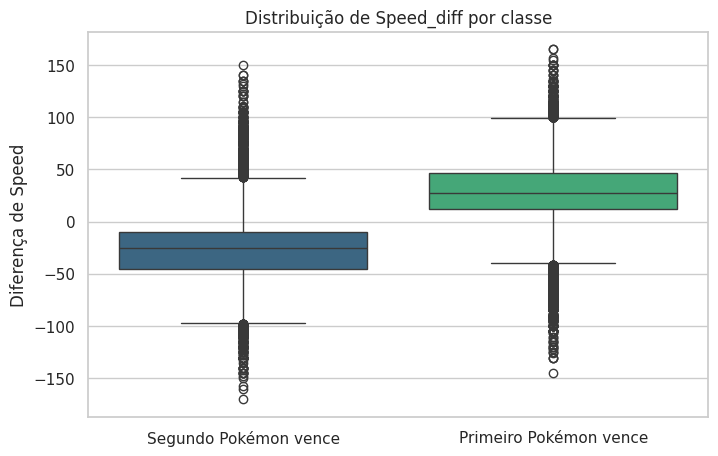

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_model,
    x="target",
    y="speed_diff",
    palette="viridis"
)

plt.xticks(
    [0,1],
    [
        "Segundo Pokémon vence",
        "Primeiro Pokémon vence"
    ]
)

plt.xlabel("")
plt.ylabel("Diferença de Speed")
plt.title("Distribuição de Speed_diff por classe")

plt.show()

In [23]:
speed_summary = (
    df_model
    .groupby("target")["speed_diff"]
    .agg(["mean","median","std"])
    .round(2)
)

speed_summary.index = [
    "Segundo Pokémon vence",
    "Primeiro Pokémon vence"
]

display(speed_summary)

,mean,median,std
Segundo Pokémon vence,-26.56,-25.0,30.83
Primeiro Pokémon vence,29.57,27.0,29.90


Observa-se que batalhas vencidas pelo primeiro Pokémon apresentam, em média, valores positivos de `speed_diff`, enquanto derrotas apresentam valores negativos.

Esse comportamento sugere que possuir vantagem de velocidade aumenta a probabilidade de vitória, indicando que essa variável poderá exercer influência relevante durante o treinamento dos modelos.

Apesar disso, nota-se uma sobreposição significativa entre as distribuições, indicando que a velocidade, isoladamente, não é suficiente para explicar o resultado das batalhas.

## 5.2 Hipótese 2 — Atributos ofensivos possuem maior influência nas batalhas do que atributos defensivos

No universo Pokémon, o desempenho em batalha é influenciado tanto por atributos ofensivos quanto defensivos.

Os atributos ofensivos são representados por:

- Attack (Ataque Físico);
- Sp. Atk (Ataque Especial).

Já os atributos defensivos são representados por:

- Defense (Defesa Física);
- Sp. Def (Defesa Especial).

A hipótese investigada nesta análise é que vantagens relacionadas aos atributos ofensivos apresentem maior capacidade de explicar o resultado das batalhas do que vantagens relacionadas aos atributos defensivos.

/tmp/ipykernel_9689/1507742602.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_9689/1507742602.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
/tmp/ipykernel_9689/1507742602.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_9689/1507742602.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
/tmp/ipykernel_9689/1507742602.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

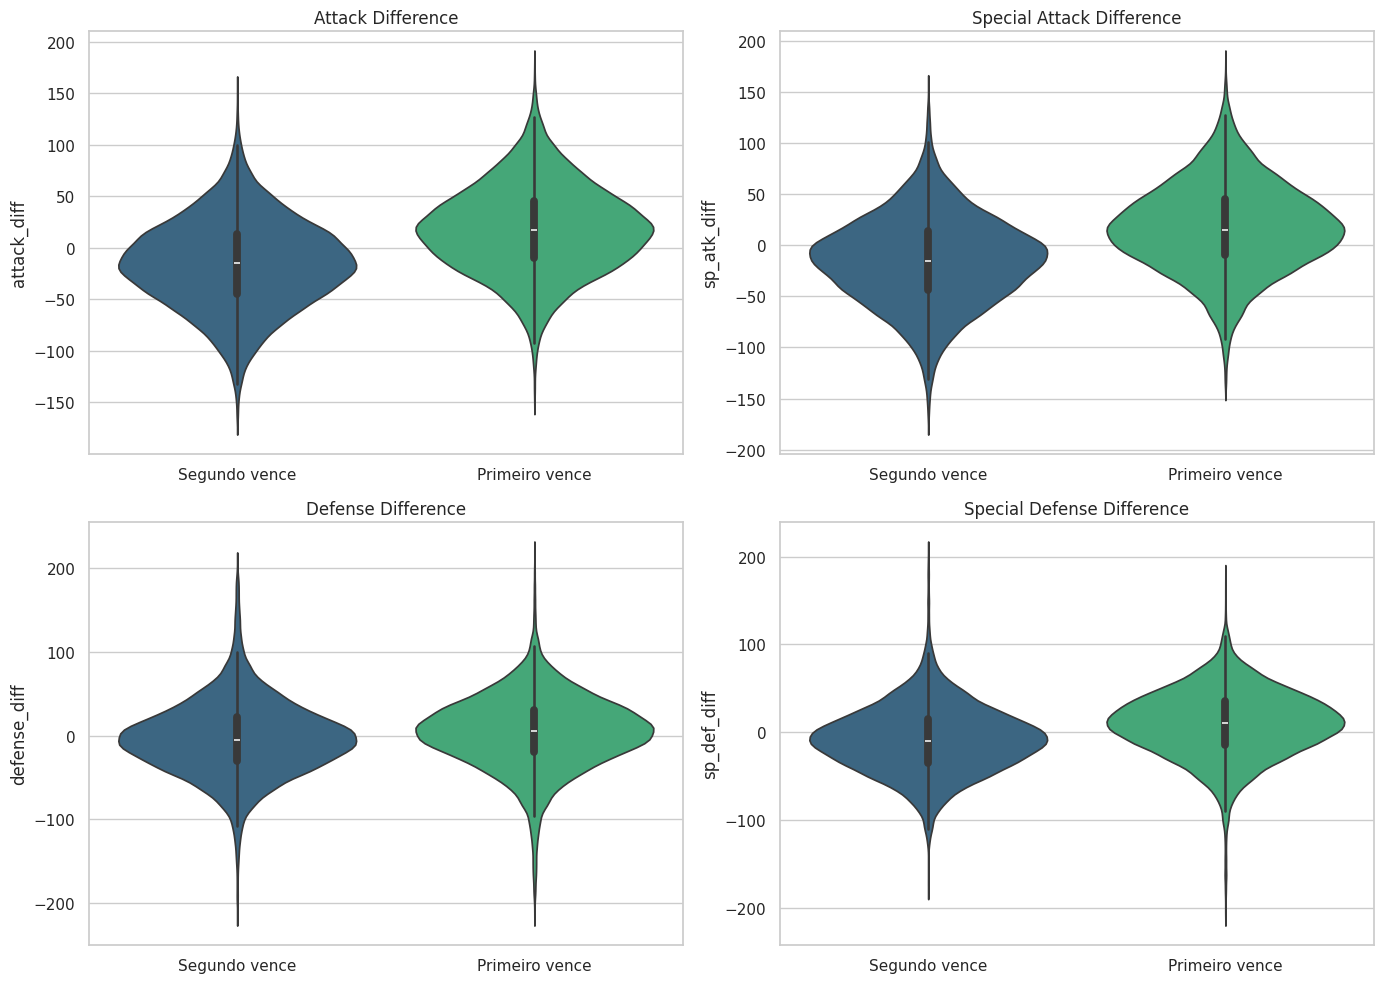

In [24]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

variables = [
    ("attack_diff", "Attack Difference"),
    ("sp_atk_diff", "Special Attack Difference"),
    ("defense_diff", "Defense Difference"),
    ("sp_def_diff", "Special Defense Difference")
]

for ax, (column, title) in zip(axes.flatten(), variables):

    sns.violinplot(
        data=df_model,
        x="target",
        y=column,
        inner="box",
        palette="viridis",
        ax=ax
    )

    ax.set_xticklabels([
        "Segundo vence",
        "Primeiro vence"
    ])

    ax.set_title(title)
    ax.set_xlabel("")

plt.tight_layout()

plt.show()

In [25]:
comparison = (
    df_model
    .groupby("target")[
        [
            "attack_diff",
            "sp_atk_diff",
            "defense_diff",
            "sp_def_diff"
        ]
    ]
    .mean()
    .round(2)
)

comparison.index = [
    "Segundo Pokémon vence",
    "Primeiro Pokémon vence"
]

display(comparison)

,attack_diff,sp_atk_diff,defense_diff,sp_def_diff
Segundo Pokémon vence,-15.71,-15.00,-3.26,-8.10
Primeiro Pokémon vence,17.75,17.27,3.85,9.19


Observa-se que as quatro variáveis apresentam comportamentos coerentes com a variável alvo, indicando que vantagens tanto ofensivas quanto defensivas influenciam o resultado das batalhas.

Entretanto, visualmente, as distribuições relacionadas aos atributos ofensivos (`attack_diff` e `sp_atk_diff`) aparentam apresentar uma separação mais evidente entre as classes quando comparadas aos atributos defensivos (`defense_diff` e `sp_def_diff`).

Esse resultado fornece indícios de que a superioridade ofensiva pode exercer maior influência sobre o desfecho das batalhas, embora essa hipótese deva ser confirmada posteriormente pelos modelos de Machine Learning por meio da análise de importância das variáveis.

## 5.3 Hipótese 3 — Pokémon lendários possuem maior taxa de vitória

Pokémon classificados como lendários normalmente apresentam atributos superiores aos demais.

Assim, espera-se que batalhas envolvendo Pokémon lendários apresentem maior probabilidade de vitória quando comparadas às demais.

/tmp/ipykernel_9689/1334915091.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


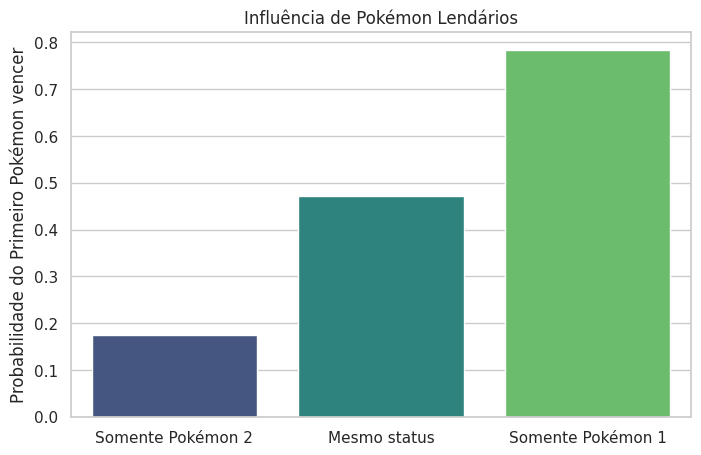

In [26]:
legendary = (
    df_model
    .groupby("legendary_diff")["target"]
    .mean()
    .reset_index()
)

legendary["Categoria"] = legendary["legendary_diff"].map({

    -1:"Somente Pokémon 2",

     0:"Mesmo status",

     1:"Somente Pokémon 1"

})

plt.figure(figsize=(8,5))

sns.barplot(
    data=legendary,
    x="Categoria",
    y="target",
    palette="viridis"
)

plt.ylabel("Probabilidade do Primeiro Pokémon vencer")
plt.xlabel("")
plt.title("Influência de Pokémon Lendários")

plt.show()

In [27]:
legendary

,legendary_diff,target,Categoria
0,-1,0.173994,Somente Pokémon 2
1,0,0.470948,Mesmo status
2,1,0.783516,Somente Pokémon 1


A análise mostra como a presença de Pokémon lendários influencia a probabilidade de vitória do primeiro competidor.

A probabilidade de vitória exarcebada _(~78%)_ quando apenas o primeiro Pokémon é lendário e mínima _(~17%)_ quando apenas o segundo é lendário, sugere que essa característica contribui positivamente para o desempenho nas batalhas.

Entretanto, essa variável deve ser analisada em conjunto com os demais atributos, uma vez que Pokémon lendários também tendem a possuir melhores estatísticas gerais.

## 5.4 Hipótese 4 — A diferença entre os atributos é mais relevante do que os valores absolutos

Durante a etapa de Engenharia de Atributos foram criadas variáveis representando a diferença entre os atributos dos dois Pokémon participantes da batalha, como `attack_diff`, `speed_diff` e `total_diff`.

A hipótese investigada nesta seção é que essas diferenças representem melhor a relação entre os competidores do que os atributos absolutos de cada Pokémon, uma vez que o resultado de uma batalha depende da comparação entre os dois adversários.

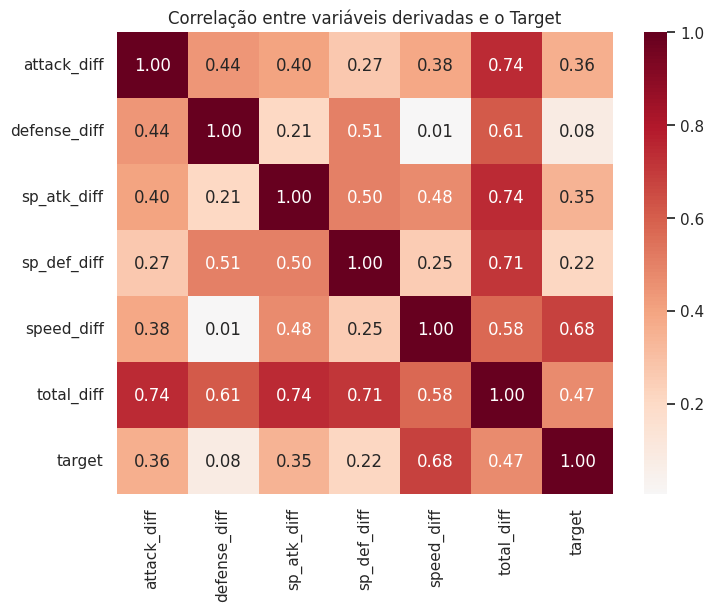

In [28]:
# Correlação entre algumas variáveis importantes e o target
correlation = (
    df_model[
        [
            "attack_diff",
            "defense_diff",
            "sp_atk_diff",
            "sp_def_diff",
            "speed_diff",
            "total_diff",
            "target"
        ]
    ]
    .corr()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Correlação entre variáveis derivadas e o Target")

plt.show()

/tmp/ipykernel_9689/3332759905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_9689/3332759905.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([
/tmp/ipykernel_9689/3332759905.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_9689/3332759905.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([


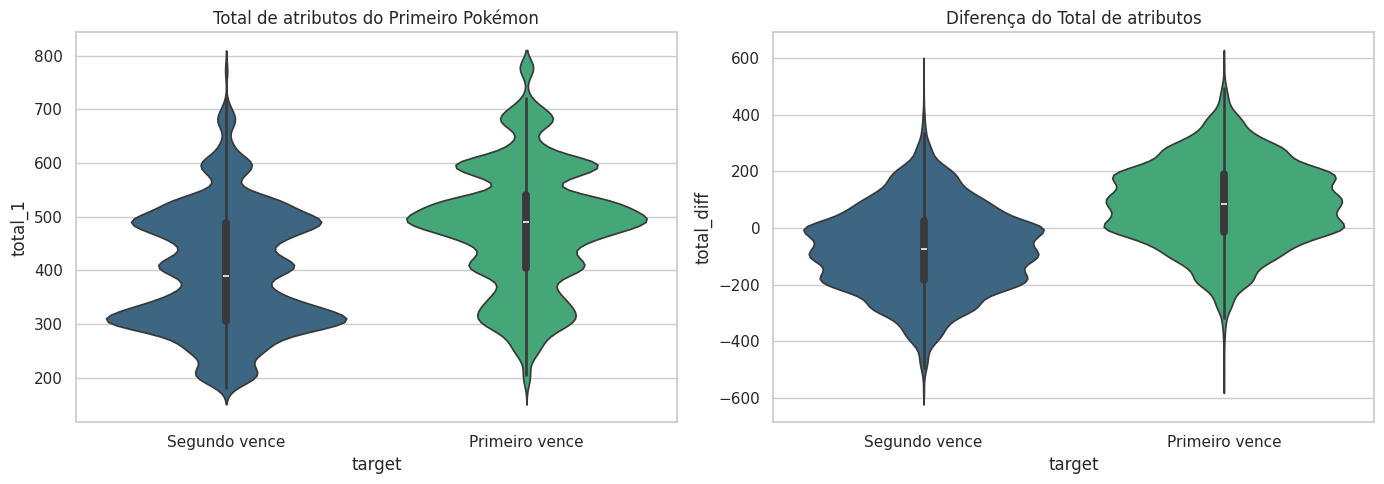

In [29]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.violinplot(
    data=df_model,
    x="target",
    y="total_1",
    inner="box",
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title("Total de atributos do Primeiro Pokémon")
axes[0].set_xticklabels([
    "Segundo vence",
    "Primeiro vence"
])

sns.violinplot(
    data=df_model,
    x="target",
    y="total_diff",
    inner="box",
    palette="viridis",
    ax=axes[1]
)

axes[1].set_title("Diferença do Total de atributos")
axes[1].set_xticklabels([
    "Segundo vence",
    "Primeiro vence"
])

plt.tight_layout()

plt.show()

A matriz de correlação evidencia que diversas variáveis derivadas apresentam associação com a variável alvo, indicando que a diferença entre os atributos dos dois Pokémon possui capacidade de explicar o resultado das batalhas.

Ao comparar os gráficos, observa-se que a variável `total_diff` apresenta maior separação entre as classes do que o atributo absoluto `total_1`. Esse comportamento reforça a ideia de que a vantagem relativa entre os competidores contém mais informação do que os valores individuais de cada Pokémon.

Esse resultado valida a estratégia adotada durante a etapa de Engenharia de Atributos, na qual foram priorizadas variáveis baseadas na comparação direta entre os adversários.

Os resultados encontrados fornecem evidências favoráveis à hipótese de que variáveis derivadas das diferenças entre os atributos representam melhor o problema de classificação do que os atributos absolutos.

Assim, a utilização dessas variáveis na construção do modelo mostra-se adequada e consistente com a natureza do problema.

## 5.5 Hipótese 5 — O primeiro Pokémon listado possui vantagem estratégica

No conjunto de dados utilizado neste projeto, o primeiro Pokémon listado realiza o primeiro movimento da batalha.

Dessa forma, investigou-se a hipótese de que essa característica possa representar uma vantagem competitiva suficiente para aumentar sua probabilidade de vitória.

In [30]:
target_distribution = (
    df_model["target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(target_distribution)

,proportion
target,
0,52.8
1,47.2


/tmp/ipykernel_9689/1316907468.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


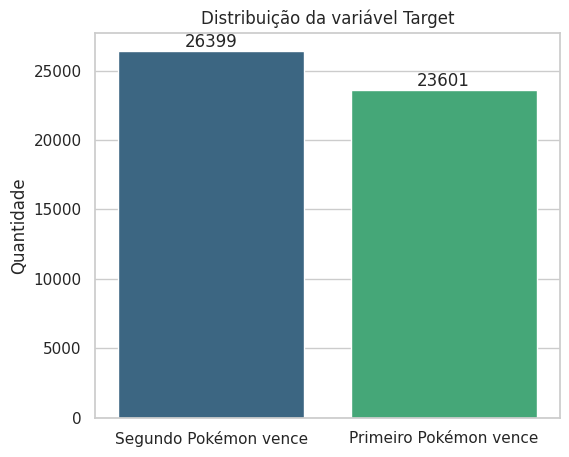

In [31]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df_model,
    x="target",
    hue="target",
    palette="viridis",
    legend=False
)

ax.set_xticklabels([
    "Segundo Pokémon vence",
    "Primeiro Pokémon vence"
])

plt.title("Distribuição da variável Target")
plt.xlabel("")
plt.ylabel("Quantidade")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

A distribuição das vitórias entre o primeiro e o segundo Pokémon apresenta comportamento relativamente equilibrado.

Embora o primeiro Pokémon realize o primeiro movimento da batalha, essa vantagem, por si só, não parece suficiente para explicar o resultado dos confrontos.

Isso indica que atributos individuais e relativo, como o nível de ataque e a diferença entre a força dos Pokémons, provavelmente possuem maior influência sobre o desfecho das batalhas do que a ordem em que aparecem na base.

## 5.6 Hipótese 6 — Os tipos dos Pokémon influenciam o resultado das batalhas

No universo Pokémon, cada criatura pertence a um ou dois tipos elementares, como Fire, Water, Grass e Electric.

Embora o dataset não contenha informações sobre vantagens e desvantagens entre os tipos (type effectiveness), espera-se que determinados tipos apresentem maior taxa de vitória devido às características naturais dos Pokémon pertencentes a essas categorias.

Nesta etapa será investigado se existe associação entre o tipo principal dos Pokémon e o resultado das batalhas.

In [32]:
# Taxa de vitória do primeiro Pokémon por Type 1
type1_winrate = (
    df_model
    .groupby("type_1_1")["target"]
    .agg(
        win_rate="mean",
        battles="count"
    )
    .reset_index()
)

type1_winrate["win_rate"] *= 100

type1_winrate = (
    type1_winrate
    .sort_values("win_rate", ascending=False)
)

/tmp/ipykernel_9689/2554664212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


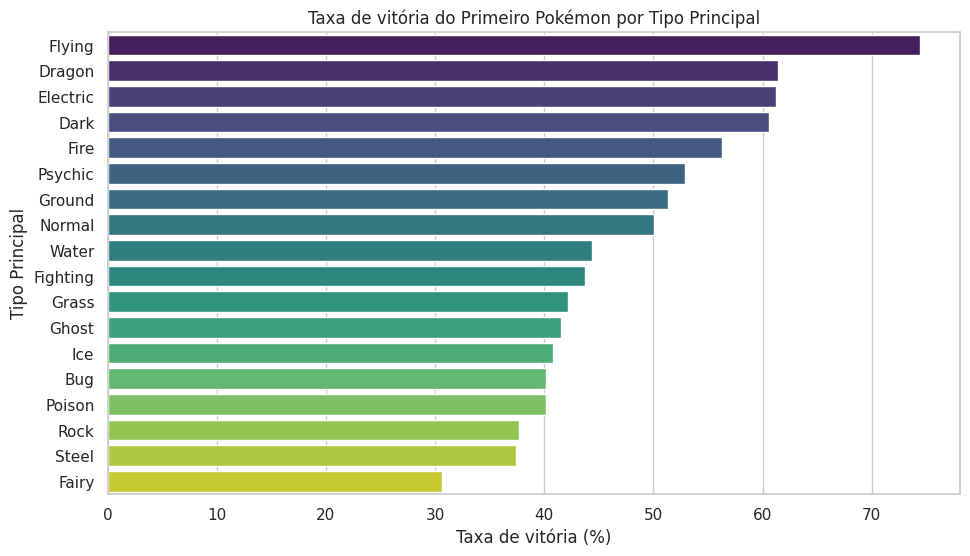

In [33]:
plt.figure(figsize=(11,6))

sns.barplot(
    data=type1_winrate,
    x="win_rate",
    y="type_1_1",
    palette="viridis"
)

plt.xlabel("Taxa de vitória (%)")
plt.ylabel("Tipo Principal")
plt.title("Taxa de vitória do Primeiro Pokémon por Tipo Principal")

plt.show()

/tmp/ipykernel_9689/1793598605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


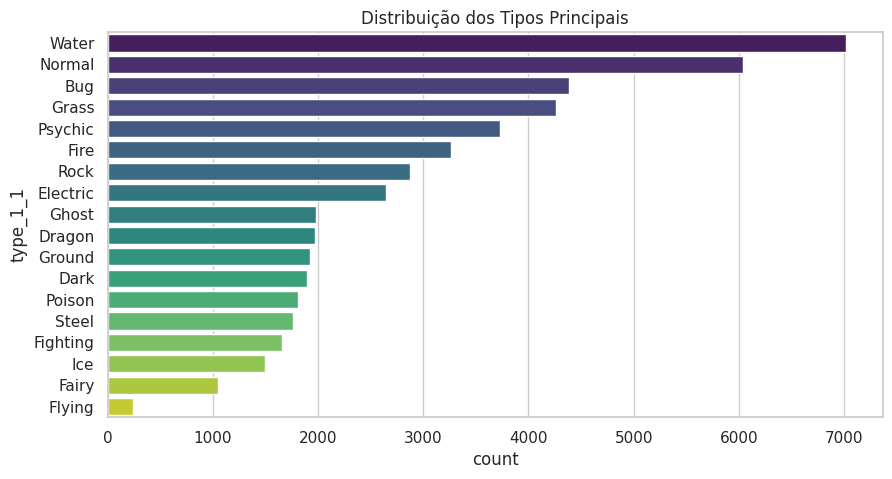

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_model,
    y="type_1_1",
    order=df_model["type_1_1"].value_counts().index,
    palette="viridis"
)

plt.title("Distribuição dos Tipos Principais")

plt.show()

In [35]:
same_type_analysis = (
    df_model
    .groupby("same_type_1")["target"]
    .mean()
    .reset_index()
)

same_type_analysis["same_type_1"] = (
    same_type_analysis["same_type_1"]
    .map({
        0:"Tipos diferentes",
        1:"Mesmo tipo"
    })
)

same_type_analysis

,same_type_1,target
0,Tipos diferentes,0.472494
1,Mesmo tipo,0.466207


/tmp/ipykernel_9689/3355501861.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


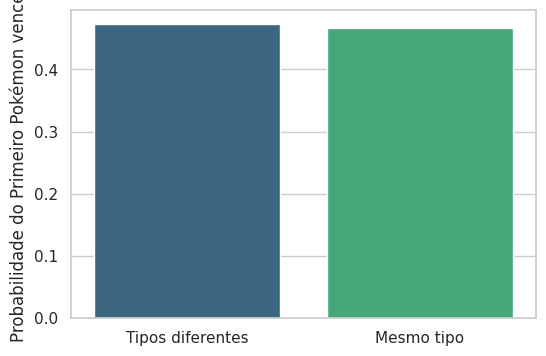

In [36]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=same_type_analysis,
    x="same_type_1",
    y="target",
    palette="viridis"
)

plt.ylabel("Probabilidade do Primeiro Pokémon vencer")
plt.xlabel("")

plt.show()



A análise exploratória indica que o tipo principal dos Pokémon apresenta associação com o resultado das batalhas, embora essa influência pareça ser menos expressiva do que a observada para atributos como velocidade, ataque e diferença total de atributos.

Ainda assim, os resultados justificam a permanência das variáveis `type_1` e `type_2` na base analítica, permitindo que os modelos de Machine Learning avaliem automaticamente a contribuição dessas informações durante o treinamento.

## 5.7 Conclusões da Análise Exploratória

De forma geral, foram observadas as seguintes hipóteses:

- **Hipótese 1:** Pokémon com vantagem de velocidade tendem a apresentar maior probabilidade de vitória, sugerindo que `speed_diff` é uma variável relevante para a modelagem.
- **Hipótese 2:** Os atributos ofensivos (`Attack` e `Sp. Atk`) demonstraram maior capacidade de discriminar o resultado das batalhas do que os atributos defensivos (`Defense` e `Sp. Def`).
- **Hipótese 3:** Pokémon lendários apresentaram indícios de desempenho superior, embora essa característica deva ser interpretada em conjunto com os demais atributos.
- **Hipótese 4:** As variáveis derivadas da diferença entre os atributos mostraram-se mais informativas do que os valores absolutos, justificando a estratégia de Engenharia de Atributos adotada na construção da base analítica.
- **Hipótese 5:** Não foram encontradas evidências de que o primeiro Pokémon listado possua vantagem suficiente para explicar, isoladamente, o resultado das batalhas.
- **Hipótese 6:** Há indicíos que o tipo principal dos Pokémon apresenta associação com o resultado das batalhas, o que justifica a permanência dessas informações durante o treinamento.

A análise exploratória permitiu compreender melhor a estrutura da base analítica e identificar características relevantes para a etapa de modelagem.

###**Impacto da EDA na estratégia de modelagem**

Os resultados da análise exploratória reforçaram a estratégia adotada durante a Engenharia de Atributos, evidenciando que variáveis derivadas das diferenças entre os atributos dos Pokémon possuem maior capacidade explicativa do que os valores absolutos. Além disso, a identificação de diferentes escalas entre as variáveis indica a necessidade de avaliar a aplicação de padronização para modelos sensíveis à escala, enquanto modelos baseados em árvores poderão ser treinados utilizando os dados em sua escala original.

###**Indícios para a escolha dos modelos**

A análise exploratória mostrou que diversas variáveis apresentam relações não lineares com a variável alvo e que a combinação de múltiplos atributos parece ser mais relevante do que a influência isolada de cada característica. Esse comportamento sugere que modelos baseados em árvores, como Decision Tree, Random Forest e Gradient Boosting, podem capturar esses padrões de forma mais eficiente. Ainda assim, será utilizada uma Regressão Logística como modelo de referência para comparação de desempenho.

# 6. Preparação dos Dados e Divisão Treino/Teste

Após a construção da Base Analítica para Modelagem e a realização da Análise Exploratória dos Dados, esta etapa tem como objetivo preparar a base para o treinamento dos modelos de Machine Learning.

Serão definidos:

- as variáveis explicativas (features);
- a variável alvo (target);
- as colunas que não participarão da modelagem;
- a estratégia de divisão entre treino e teste.

Essa preparação garante que o processo de treinamento e avaliação dos modelos seja realizado de forma organizada e reprodutível.

## 6.1 Definição das variáveis explicativas e da variável alvo

A variável alvo do problema é `target`, construída durante a etapa de Engenharia de Atributos.

Sua definição é dada por:

- **1:** o primeiro Pokémon venceu a batalha;
- **0:** o segundo Pokémon venceu a batalha.

Todas as demais colunas da base analítica serão consideradas variáveis explicativas para o treinamento dos modelos.

In [37]:
# Variáveis explicativas (features)
X = df_model.drop(columns=["target"])

# Variável alvo
y = df_model["target"]

print(f"Quantidade de observações: {X.shape[0]}")
print(f"Quantidade de variáveis explicativas: {X.shape[1]}")

Quantidade de observações: 50000
Quantidade de variáveis explicativas: 40


## 6.2 Colunas removidas da modelagem

Durante a construção da Base Analítica foram removidas algumas colunas que não deveriam participar diretamente do treinamento dos modelos.

Essas variáveis foram utilizadas apenas durante o processo de integração entre as bases e criação das novas features.

As principais colunas removidas foram:

- identificadores dos Pokémon (`pokemon_1_id`, `pokemon_2_id`);
- identificadores auxiliares utilizados nos joins;
- nomes dos Pokémon;
- variável original `winner`.

A remoção dessas colunas evita que o modelo memorize identificadores específicos em vez de aprender padrões relacionados às características dos Pokémon.

In [38]:
print("Variáveis utilizadas no treinamento:")

display(X.columns.to_frame(name="Variável"))

Variáveis utilizadas no treinamento:


,Variável
type_1_1,type_1_1
type_2_1,type_2_1
hp_1,hp_1
attack_1,attack_1
defense_1,defense_1
sp_atk_1,sp_atk_1
sp_def_1,sp_def_1
speed_1,speed_1
generation_1,generation_1
legendary_1,legendary_1


## 6.3 Divisão entre treino e teste

Para avaliar a capacidade de generalização dos modelos, a base será dividida em dois subconjuntos:

- **Treino (80%)**, utilizado para o ajuste dos modelos;
- **Teste (20%)**, utilizado exclusivamente para avaliação final do desempenho.

A divisão será realizada de forma estratificada (`stratify=y`), preservando a proporção das classes observada na variável alvo.

Essa estratégia é amplamente utilizada em problemas de classificação e reduz o risco de obtenção de conjuntos com distribuições muito diferentes entre si.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Treino")

print(X_train.shape)

print(y_train.shape)

print()

print("Teste")

print(X_test.shape)

print(y_test.shape)

Treino
(40000, 40)
(40000,)

Teste
(10000, 40)
(10000,)


In [40]:
#Verificação da Divisão
distribution = pd.DataFrame({

    "Base Completa": y.value_counts(normalize=True),

    "Treino": y_train.value_counts(normalize=True),

    "Teste": y_test.value_counts(normalize=True)

}).mul(100).round(2)

distribution.index = [
    "Segundo Pokémon vence",
    "Primeiro Pokémon vence"
]

distribution

,Base Completa,Treino,Teste
Segundo Pokémon vence,52.8,52.8,52.8
Primeiro Pokémon vence,47.2,47.2,47.2


Esse resultado demonstra que a divisão estratificada foi eficiente em preservar a representatividade da variável alvo, contribuindo para uma avaliação mais confiável dos modelos.

## 6.4 Estratégia de validação

O conjunto de teste será reservado exclusivamente para a avaliação final dos modelos, não participando de nenhuma etapa de treinamento.

Durante a etapa de comparação dos algoritmos e ajuste de hiperparâmetros será utilizada validação cruzada (*Cross Validation*) sobre o conjunto de treino.

Essa estratégia reduz a dependência de uma única divisão dos dados e fornece estimativas mais robustas do desempenho dos modelos.

Somente após a definição do modelo final será realizada a avaliação utilizando o conjunto de teste, simulando o comportamento esperado em dados inéditos.

## 6.5 Justificativa da estratégia adotada

A estratégia adotada neste projeto busca garantir que o desempenho dos modelos seja avaliado de forma justa e representativa.

A utilização de uma divisão estratificada preserva a distribuição da variável alvo entre treino e teste, enquanto a reserva do conjunto de teste evita vazamento de informações durante o desenvolvimento dos modelos.

Além disso, a utilização de validação cruzada apenas sobre o conjunto de treino permitirá comparar diferentes algoritmos e ajustar hiperparâmetros sem comprometer a imparcialidade da avaliação final.

# 7. Pré-processamento e Pipeline
Nesta etapa serão definidos os tratamentos necessários para cada tipo de variável, garantindo que todas as transformações sejam aprendidas exclusivamente a partir do conjunto de treino.

Para isso será utilizado o módulo `Pipeline` do Scikit-Learn, permitindo integrar o pré-processamento e os modelos em um único fluxo reprodutível e reduzindo o risco de vazamento de dados.


## 7.1 Estratégia de Pré-processamento

Com base na análise exploratória realizada anteriormente, foram definidas as seguintes estratégias para tratamento dos dados:

### Variáveis numéricas

As variáveis numéricas serão submetidas às seguintes etapas:

- imputação pela mediana, como medida preventiva para eventuais valores ausentes;
- padronização utilizando `StandardScaler`, reduzindo diferenças de escala entre os atributos e beneficiando algoritmos sensíveis à magnitude das variáveis.

### Variáveis categóricas

As variáveis categóricas serão tratadas através de:

- imputação pelo valor mais frequente;
- codificação utilizando `OneHotEncoder`, permitindo que os algoritmos utilizem informações como tipo principal, tipo secundário e geração dos Pokémon.

### Engenharia de atributos

As variáveis derivadas utilizadas neste projeto (como `attack_diff`, `speed_diff` e `total_diff`) foram construídas na etapa de preparação da Base Analítica e passam a compor diretamente o conjunto de variáveis explicativas.

In [41]:
# Separação das variáveis por tipo
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "bool"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Variáveis numéricas ({len(numeric_features)}):")
print(numeric_features)

print()

print(f"Variáveis categóricas ({len(categorical_features)}):")
print(categorical_features)

Variáveis numéricas (36):
['hp_1', 'attack_1', 'defense_1', 'sp_atk_1', 'sp_def_1', 'speed_1', 'generation_1', 'legendary_1', 'hp_2', 'attack_2', 'defense_2', 'sp_atk_2', 'sp_def_2', 'speed_2', 'generation_2', 'legendary_2', 'hp_diff', 'attack_diff', 'defense_diff', 'sp_atk_diff', 'sp_def_diff', 'speed_diff', 'total_1', 'total_2', 'total_diff', 'generation_diff', 'legendary_diff', 'pokemon_1_has_higher_hp', 'pokemon_1_has_higher_attack', 'pokemon_1_has_higher_defense', 'pokemon_1_has_higher_speed', 'pokemon_1_has_higher_total', 'same_type_1', 'same_type_2', 'pokemon_1_has_type_2', 'pokemon_2_has_type_2']

Variáveis categóricas (4):
['type_1_1', 'type_2_1', 'type_1_2', 'type_2_2']


## 7.2 Pipeline para Variáveis Numéricas

Embora a base analítica não apresente valores ausentes após o processo de preparação dos dados, será mantida uma etapa de imputação pela mediana.

Essa decisão torna o pipeline mais robusto e permite sua reutilização em novas bases de dados sem necessidade de modificações.

Na sequência será aplicada a padronização utilizando `StandardScaler`, necessária principalmente para modelos como Regressão Logística.

In [42]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## 7.3 Pipeline para Variáveis Categóricas

As variáveis categóricas serão codificadas utilizando One-Hot Encoding.

Essa abordagem cria uma variável binária para cada categoria existente, permitindo que algoritmos supervisionados utilizem essas informações sem assumir qualquer relação ordinal entre as categorias.

Além disso, o parâmetro `handle_unknown="ignore"` garante que categorias não observadas durante o treinamento não provoquem erros durante a etapa de predição.

In [43]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

## 7.4 Construção do Pipeline de Pré-processamento

Os pipelines definidos para variáveis numéricas e categóricas serão integrados utilizando `ColumnTransformer`.

Essa abordagem permite aplicar automaticamente o tratamento adequado para cada grupo de variáveis, mantendo todo o processo encapsulado em uma única estrutura reutilizável.

In [44]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        )

    ]
)

preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['hp_1', 'attack_1', 'defense_1', 'sp_atk_1',
                                  'sp_def_1', 'speed_1', 'generation_1',
                                  'legendary_1', 'hp_2', 'attack_2',
                                  'defense_2', 'sp_atk_2', 'sp_def_2',
                                  'speed_2', 'generation_2', 'legendary_2',
                                  'hp_diff', 'attack_diff', 'defense_...
                                  'sp_atk_diff', 'sp_def_diff', 'speed_diff',
                                  'total_1', 'total_2', 'total_diff',
                                  'generation_diff', 'legendary_diff',
                                  'pokemon_1_has_higher_hp',
                                  'pokemon_1_has_higher_attack',
                                  'pokemon_1_has_higher_defense', ...]),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['type_1_1', 'type_2_1', 'type_1_2',
                                  'type_2_2'])])

## 7.5 Teste do Pipeline

Antes de iniciar o treinamento dos modelos, será realizado um teste para verificar se todas as transformações podem ser aplicadas corretamente ao conjunto de treino.

Essa verificação reduz a possibilidade de erros durante as etapas seguintes do projeto.

In [45]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Treino:")

print(X_train_processed.shape)

print()

print("Teste:")

print(X_test_processed.shape)

Treino:
(40000, 110)

Teste:
(10000, 110)


## 7.6 Prevenção de Vazamento de Dados

Uma preocupação importante em projetos de Machine Learning é evitar o vazamento de dados (*Data Leakage*).

Neste projeto, todas as etapas de pré-processamento serão ajustadas exclusivamente sobre o conjunto de treino (`fit`) e posteriormente aplicadas ao conjunto de teste (`transform`).

Dessa forma, nenhuma informação proveniente do conjunto de teste influencia o treinamento dos modelos, garantindo que a avaliação final represente adequadamente o desempenho esperado em dados inéditos.

Essa estratégia é implementada naturalmente pelo uso de `Pipeline` e `ColumnTransformer`, que encapsulam todas as transformações em um fluxo único e reprodutível.

# 8. Baseline e Modelos Candidatos

Inicialmente será construído um modelo baseline utilizando **Regressão Logística**. Esse modelo será utilizado como referência supervisionada simples, permitindo avaliar se modelos mais complexos, como árvores de decisão e métodos ensemble, conseguem obter ganhos relevantes de desempenho.

Em seguida serão avaliados diferentes algoritmos supervisionados, permitindo comparar seus desempenhos antes da etapa de otimização de hiperparâmetros.


## 8.1 Modelo Baseline com Validação Cruzada

A Regressão Logística é um dos algoritmos mais utilizados como modelo de referência em problemas de classificação supervisionada devido à sua simplicidade, facilidade de interpretação e baixo custo computacional. Embora seja um modelo linear, ela é capaz de aprender relações entre as variáveis explicativas e a variável alvo, estabelecendo um ponto de partida para avaliar se modelos mais complexos são capazes de obter ganhos significativos de desempenho.

A avaliação do modelo será realizada por meio de validação cruzada sobre o conjunto de treino, preservando o conjunto de teste para a avaliação final do modelo selecionado.

In [46]:
from sklearn.model_selection import cross_validate
from sklearn.base import clone

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

results = {}

# Modelo baseline
baseline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            LogisticRegression(
                random_state=SEED,
                max_iter=1000
            )
        )
    ]
)

# Avaliação por validação cruzada
baseline_scores = cross_validate(
    estimator=baseline,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Armazenamento dos resultados
results["Baseline (Logistic Regression)"] = {
    "Accuracy": baseline_scores["test_accuracy"].mean(),
    "Precision": baseline_scores["test_precision"].mean(),
    "Recall": baseline_scores["test_recall"].mean(),
    "F1-Score": baseline_scores["test_f1"].mean()
}

results["Baseline (Logistic Regression)"]

{'Accuracy': np.float64(0.944475),
 'Precision': np.float64(0.9365645570551443),
 'Recall': np.float64(0.946507266326517),
 'F1-Score': np.float64(0.9415016466546984)}

## 8.2 Modelos Candidatos

Serão avaliados diferentes algoritmos de classificação, representando abordagens lineares e não lineares.

Os modelos candidatos são:

- **Logistic Regression:** modelo linear utilizado como referência supervisionada;
- **Decision Tree:** modelo baseado em regras de decisão;
- **Random Forest:** ensemble de árvores baseado em Bagging;
- **Gradient Boosting:** ensemble sequencial baseado em Boosting.

Todos os modelos utilizarão o mesmo pipeline de pré-processamento, garantindo uma comparação justa. A comparação inicial dos modelos será realizada utilizando validação cruzada com 5 partições (`cv=5`) sobre o conjunto de treino.

Essa estratégia permite estimar o desempenho médio de cada algoritmo em diferentes subconjuntos dos dados, reduzindo a dependência de uma única divisão treino/validação.

In [47]:
#Criação dos modelos
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=SEED
    )
}

#Loop de treinamento
for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-Score": scores["test_f1"].mean()
    }

## 8.3 Comparação dos Resultados

In [48]:
results_df = (
    pd.DataFrame(results)
    .T
    .sort_values(by="Accuracy", ascending=False)
    .round(4)
)

results_df

,Accuracy,Precision,Recall,F1-Score
Gradient Boosting,0.9627,0.9571,0.9643,0.9607
Decision Tree,0.9586,0.9569,0.9552,0.9561
Random Forest,0.9582,0.9499,0.9622,0.9560
Baseline (Logistic Regression),0.9445,0.9366,0.9465,0.9415


/tmp/ipykernel_9689/3995266059.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


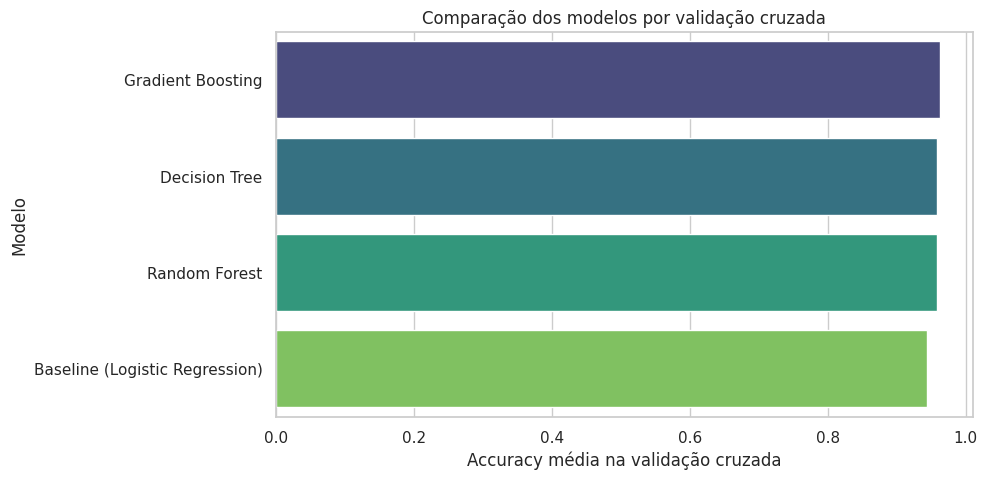

In [49]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=results_df.reset_index(),
    x="Accuracy",
    y="index",
    palette="viridis"
)

plt.xlabel("Accuracy média na validação cruzada")
plt.ylabel("Modelo")
plt.title("Comparação dos modelos por validação cruzada")

plt.show()

<Figure size 1000x500 with 0 Axes>

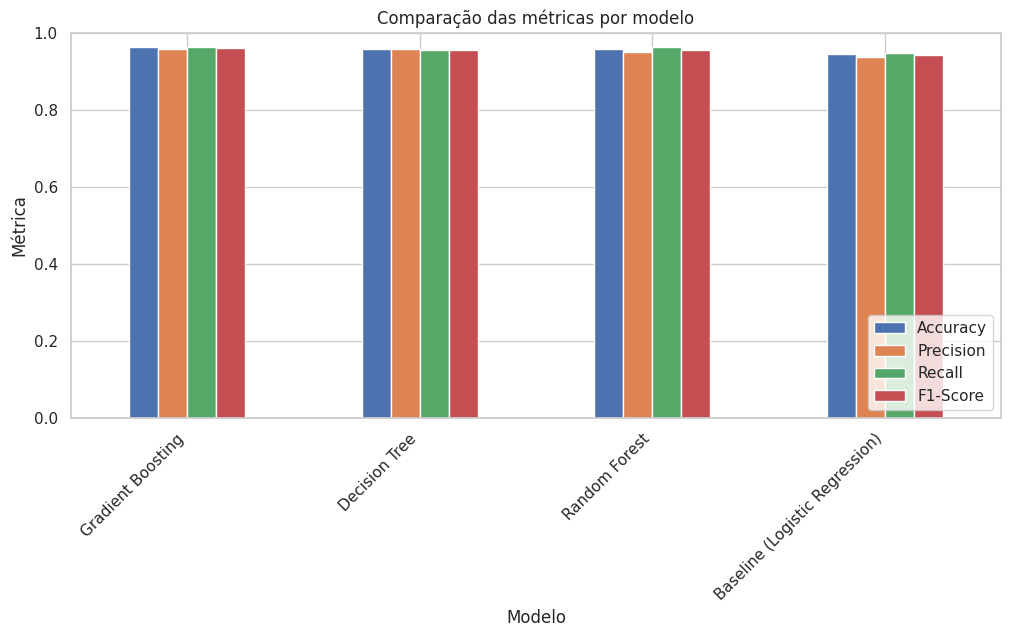

In [50]:
plt.figure(figsize=(10,5))

results_df[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Comparação das métricas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Métrica")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

Os resultados demonstraram que todos os modelos candidatos superaram o modelo baseline, representado pela **Regressão Logística**. Embora esse modelo tenha alcançado uma acurácia de **94,45%**, os algoritmos baseados em árvores apresentaram desempenho superior, indicando que foram capazes de capturar padrões mais complexos presentes na base de dados.

Como o problema apresenta uma distribuição equilibrada entre as classes, a **Accuracy** mostrou-se uma métrica adequada para a comparação inicial dos modelos. Entretanto, ela não foi utilizada de forma isolada. As métricas **Precision**, **Recall** e **F1-Score** também foram analisadas, permitindo verificar que o desempenho dos modelos permaneceu consistente sob diferentes perspectivas de avaliação.

Entre os modelos avaliados, o **Gradient Boosting** apresentou o melhor desempenho médio, alcançando **96,27% de Accuracy**, **95,71% de Precision**, **96,43% de Recall** e **96,07% de F1-Score**, sendo selecionado para a etapa de otimização dos hiperparâmetros.

Não foram observados indícios de **underfitting** durante a comparação por validação cruzada. Mesmo o modelo baseline apresentou desempenho elevado, indicando que a base analítica contém atributos capazes de explicar adequadamente o resultado das batalhas. O desempenho superior dos modelos baseados em árvores sugere, entretanto, que existem relações não lineares entre as variáveis que não são totalmente capturadas por um modelo linear como a Regressão Logística.

Em relação ao custo computacional, o tempo de treinamento mostrou-se adequado para todos os algoritmos avaliados, permitindo a utilização de validação cruzada sem comprometer a viabilidade do experimento. Esse comportamento é compatível com o tamanho do conjunto de dados utilizado neste MVP.

Por fim, os resultados obtidos estão alinhados com as evidências observadas durante a Análise Exploratória dos Dados. As hipóteses de que diferenças entre atributos, velocidade, características ofensivas e relações não lineares exercem influência no resultado das batalhas são reforçadas pelo melhor desempenho dos modelos baseados em árvores, especialmente do **Gradient Boosting**.

Dessa forma, o **Gradient Boosting** foi selecionado para a etapa de otimização dos hiperparâmetros, por apresentar o melhor desempenho médio entre os modelos avaliados e o melhor equilíbrio entre Accuracy, Precision, Recall e F1-Score.

# 9. Validação e Otimização de Hiperparâmetros

O objetivo desta etapa é identificar uma combinação de hiperparâmetros que maximize a capacidade preditiva do modelo, mantendo uma boa capacidade de generalização.

Para isso será utilizada a técnica de **RandomizedSearchCV**, que avalia diferentes combinações de hiperparâmetros utilizando validação cruzada sobre o conjunto de treino.

## 9.1 Hiperparâmetros Avaliados

Os principais hiperparâmetros do Gradient Boosting que influenciam o desempenho do modelo foram selecionados para otimização.

Foram considerados:

- **n_estimators:** quantidade de árvores utilizadas pelo algoritmo;
- **learning_rate:** taxa de aprendizado do Boosting;
- **max_depth:** profundidade máxima das árvores;
- **min_samples_split:** número mínimo de amostras para realizar uma divisão;
- **min_samples_leaf:** número mínimo de amostras em uma folha;
- **subsample:** fração das amostras utilizada em cada árvore.

In [51]:
param_distributions = {

    "classifier__n_estimators": [100, 150, 200],

    "classifier__learning_rate": [
        0.05,
        0.1,
        0.2
    ],

    "classifier__max_depth": [
        2,
        3
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ],

    "classifier__subsample": [
        0.8,
        1.0
    ]
}

In [52]:
#Pipeline do Modelo
gb_pipeline = Pipeline(

    steps=[

        ("preprocessor", clone(preprocessor)),

        (
            "classifier",
            GradientBoostingClassifier(
                random_state=SEED
            )
        )

    ]

)

## 9.2 Estratégia de Validação

A otimização será realizada utilizando **RandomizedSearchCV**.

Essa abordagem permite explorar diferentes combinações de hiperparâmetros de forma eficiente, reduzindo o custo computacional quando comparada ao Grid Search.

Será utilizada validação cruzada com três partições (`cv=3`) e a **Accuracy** será utilizada como métrica principal para seleção do melhor modelo, uma vez que o problema apresenta distribuição equilibrada entre as classes.

In [53]:
random_search = RandomizedSearchCV(

    estimator=gb_pipeline,

    param_distributions=param_distributions,

    n_iter=10,

    scoring="accuracy",

    cv=3,

    random_state=SEED,

    n_jobs=-1,

    verbose=1

)

In [54]:
random_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['hp_1',
                                                                                'attack_1',
                                                                                'defense_1',
                                                                                'sp_atk_1',
                                                                                'sp_def_1',
                                                                                'speed_1',
                                                                                'generation_1',
                                                                                'legendary_1',
                                                                                'hp_2',
                                                                                'attack_2',
                                                                                'defense_2',
                                                                                'sp_atk_2',
                                                                                'sp_def_2',
                                                                                'speed...
                                              GradientBoostingClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__learning_rate': [0.05, 0.1,
                                                                      0.2],
                                        'classifier__max_depth': [2, 3],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 150,
                                                                     200],
                                        'classifier__subsample': [0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

**Nota:** O processo levou 9 minutos para ser executado

In [55]:
print("Melhores hiperparâmetros:\n")

random_search.best_params_

Melhores hiperparâmetros:



{'classifier__subsample': 0.8,
 'classifier__n_estimators': 200,
 'classifier__min_samples_split': 10,
 'classifier__min_samples_leaf': 2,
 'classifier__max_depth': 3,
 'classifier__learning_rate': 0.1}

In [56]:
print(
    f"Melhor Accuracy média: {random_search.best_score_:.4f}"
)

Melhor Accuracy média: 0.9680


In [57]:
best_model = random_search.best_estimator_

## 9.6 Discussão dos Resultados

Com a configuração de hiperparâmetros encontrada, o modelo alcançou uma **Accuracy média de 96,80%** durante a validação cruzada, resultado ligeiramente superior ao obtido antes da etapa de otimização, indicando um pequeno ganho na capacidade de generalização.

A busca pelos melhores hiperparâmetros foi realizada por meio do `RandomizedSearchCV`, utilizando um espaço de busca reduzido (`n_iter = 10` e `cv = 3`). Essa configuração foi adotada para equilibrar qualidade da otimização e custo computacional, considerando o tamanho da base de dados e o escopo de um MVP.

Os hiperparâmetros selecionados mostram-se coerentes com o problema, especialmente a profundidade moderada das árvores (`max_depth = 3`) e o uso de `subsample = 0,8`, que contribuem para reduzir o risco de sobreajuste e favorecer a capacidade de generalização do modelo.

Caso houvesse maior disponibilidade de tempo e recursos computacionais, seria interessante ampliar o espaço de busca, aumentando o número de iterações do `RandomizedSearchCV` e avaliando outras combinações de hiperparâmetros. Entretanto, os resultados obtidos demonstram que a configuração encontrada já apresenta excelente desempenho para os objetivos deste projeto.


# 10. Avaliação Final no Conjunto de Teste

Após a seleção do modelo e a otimização de seus hiperparâmetros, foi realizada a avaliação final utilizando o conjunto de teste reservado desde a etapa de preparação dos dados.

Como esse conjunto não participou do treinamento nem do processo de seleção dos modelos ou otimização dos hiperparâmetros, os resultados apresentados nesta seção representam uma estimativa do desempenho esperado do modelo em dados inéditos.

Além da avaliação por meio das métricas de classificação, será realizada uma comparação com o modelo baseline, bem como uma análise dos erros, da capacidade de generalização e das limitações da solução proposta.

In [62]:
# Previsões do modelo otimizado
y_pred = best_model.predict(X_test)

## 10.1 Métricas de Avaliação

As mesmas métricas utilizadas durante a validação cruzada serão empregadas na avaliação final do modelo:

- Accuracy;
- Precision;
- Recall;
- F1-Score.

A utilização das mesmas métricas facilita a comparação entre os resultados obtidos durante a validação e aqueles observados no conjunto de teste.

In [63]:
final_metrics = pd.DataFrame({

    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Valor":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred)
    ]

})

display(final_metrics)

,Métrica,Valor
0,Accuracy,0.969400
1,Precision,0.968976
2,Recall,0.966102
3,F1-Score,0.967537


## 10.2 Comparação com o Modelo Baseline

Após a avaliação do modelo otimizado, seus resultados foram comparados com o desempenho do modelo baseline (Regressão Logística).

Essa comparação permite verificar se o aumento de complexidade proporcionado pelo Gradient Boosting resultou em ganhos efetivos de desempenho.

In [64]:
comparison = pd.DataFrame({

    "Modelo":[
        "Baseline\n(Logistic Regression)",
        "Gradient Boosting"
    ],

    "Accuracy":[

        results["Baseline (Logistic Regression)"]["Accuracy"],

        accuracy_score(y_test,y_pred)

    ]

})

comparison

,Modelo,Accuracy
0,Baseline\n(Logistic Regression),0.944475
1,Gradient Boosting,0.969400


/tmp/ipykernel_9689/2922004140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


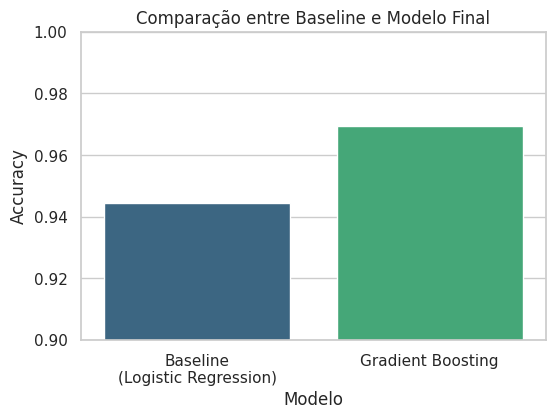

In [65]:
plt.figure(figsize=(6,4))

sns.barplot(

    data=comparison,

    x="Modelo",

    y="Accuracy",

    palette="viridis"

)

plt.ylim(0.9,1)

plt.ylabel("Accuracy")

plt.title("Comparação entre Baseline e Modelo Final")

plt.show()

## 10.3 Análise dos Erros

A matriz de confusão permite analisar quais tipos de erros foram cometidos pelo modelo durante a classificação das batalhas, evidenciando a quantidade de previsões corretas e incorretas para cada classe.

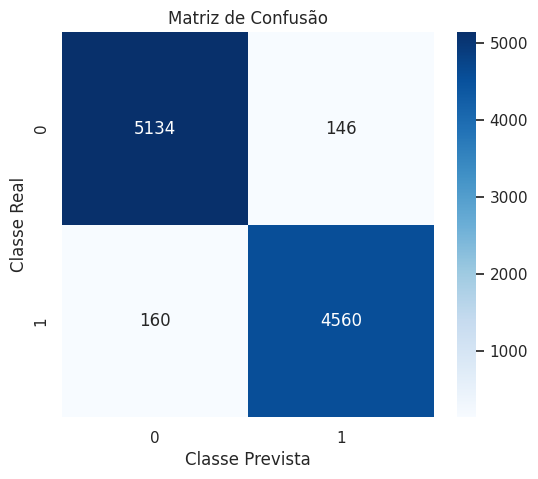

In [66]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Classe Prevista")

plt.ylabel("Classe Real")

plt.title("Matriz de Confusão")

plt.show()

In [67]:
print(

classification_report(

    y_test,

    y_pred

)

)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5280
           1       0.97      0.97      0.97      4720

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## 10.4 Discussão dos Resultados

A avaliação realizada sobre o conjunto de teste confirmou que o modelo otimizado manteve elevado desempenho em dados não utilizados durante o treinamento.

O Gradient Boosting apresentou desempenho superior ao modelo baseline, indicando que a utilização de um algoritmo capaz de modelar relações não lineares proporcionou ganhos na capacidade preditiva em relação à Regressão Logística.

A matriz de confusão evidencia que a maior parte das batalhas foi corretamente classificada, enquanto o relatório de classificação demonstra equilíbrio entre Precision e Recall, indicando que o modelo apresenta desempenho consistente para ambas as classes da variável alvo.

## 10.5 Discussão sobre Overfitting e Underfitting

Durante a etapa de otimização, o modelo apresentou **Accuracy média de 96,80%** na validação cruzada.

Ao comparar esse resultado com a Accuracy obtida no conjunto de teste, observa-se que os desempenhos permaneceram próximos, sugerindo boa capacidade de generalização.

Dessa forma, não foram identificados indícios relevantes de overfitting, uma vez que o modelo manteve desempenho consistente em dados inéditos.

Também não foram observados sinais de underfitting, já que o modelo apresentou elevado desempenho tanto durante a validação quanto na avaliação final.

## 10.6 Limitações da Solução

Apesar do excelente desempenho obtido, algumas limitações devem ser consideradas.

O modelo foi desenvolvido utilizando exclusivamente as informações disponíveis no dataset. Características importantes do universo Pokémon, como vantagens entre tipos (*type effectiveness*), habilidades (*abilities*), golpes (*moves*), itens equipados e condições específicas das batalhas não estão presentes na base de dados e, consequentemente, não puderam ser exploradas durante o treinamento.

Além disso, a otimização dos hiperparâmetros foi realizada utilizando um espaço de busca reduzido, compatível com o escopo deste MVP. Em trabalhos futuros, seria possível ampliar esse espaço de busca e avaliar outros algoritmos baseados em boosting, como XGBoost ou LightGBM, buscando possíveis ganhos adicionais de desempenho.

## 10.7 Conclusão da Avaliação

A avaliação final confirmou que o modelo **Gradient Boosting** otimizado apresentou excelente capacidade de generalização, mantendo desempenho consistente no conjunto de teste e superando o modelo baseline baseado em Regressão Logística.

Os resultados reforçam que a estratégia de Engenharia de Atributos adotada neste projeto foi eficaz, permitindo que o modelo identificasse padrões relevantes para prever corretamente o vencedor das batalhas Pokémon.

Dessa forma, considera-se que o objetivo proposto para este MVP foi atingido, demonstrando que técnicas de Machine Learning supervisionado podem ser utilizadas com sucesso para prever o resultado de batalhas a partir das características dos Pokémon participantes.

# 11. Comparação final dos modelos



In [72]:
comparison_table = pd.DataFrame({

    "Modelo": [
        "Baseline (Logistic Regression)",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Gradient Boosting (Otimizado)"
    ],

    "Base de avaliação": [
        "Validação cruzada",
        "Validação cruzada",
        "Validação cruzada",
        "Validação cruzada",
        "Teste"
    ],

    "Accuracy": [
        0.9445,
        0.9586,
        0.9582,
        0.9627,
        accuracy_score(y_test, y_pred)
    ],

    "Precision": [
        0.9366,
        0.9569,
        0.9499,
        0.9571,
        precision_score(y_test, y_pred)
    ],

    "Recall": [
        0.9465,
        0.9552,
        0.9622,
        0.9643,
        recall_score(y_test, y_pred)
    ],

    "F1-Score": [
        0.9415,
        0.9561,
        0.9560,
        0.9607,
        f1_score(y_test, y_pred)
    ],

    "Tempo de treino": [
        "Baixo (segundos)",
        "Baixo (segundos)",
        "Moderado (poucos minutos)",
        "Moderado (poucos minutos)",
        "Moderado/Alto (~9 minutos)"
    ],

    "Observações": [
        "Modelo linear utilizado como baseline.",
        "Árvore simples, boa interpretabilidade.",
        "Ensemble robusto, desempenho próximo ao da Decision Tree.",
        "Melhor modelo antes da otimização.",
        "Modelo final após otimização de hiperparâmetros."
    ]

})

comparison_table = comparison_table.round({
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1-Score": 4
})

display(comparison_table)

,Modelo,Base de avaliação,Accuracy,Precision,Recall,F1-Score,Tempo de treino,Observações
0,Baseline (Logistic Regression),Validação cruzada,0.9445,0.9366,0.9465,0.9415,Baixo (segundos),Modelo linear utilizado como baseline.
1,Decision Tree,Validação cruzada,0.9586,0.9569,0.9552,0.9561,Baixo (segundos),"Árvore simples, boa interpretabilidade."
2,Random Forest,Validação cruzada,0.9582,0.9499,0.9622,0.9560,Moderado (poucos minutos),"Ensemble robusto, desempenho próximo ao da Dec..."
3,Gradient Boosting,Validação cruzada,0.9627,0.9571,0.9643,0.9607,Moderado (poucos minutos),Melhor modelo antes da otimização.
4,Gradient Boosting (Otimizado),Teste,0.9694,0.9690,0.9661,0.9675,Moderado/Alto (~9 minutos),Modelo final após otimização de hiperparâmetros.


# 12. Boas Práticas e Rastreabilidade

Ao longo do desenvolvimento deste MVP foram adotadas práticas que visam garantir a reprodutibilidade dos experimentos, a organização do código e a transparência das decisões tomadas durante a construção do modelo.

A tabela a seguir resume as principais decisões metodológicas adotadas e seus respectivos impactos esperados sobre o desempenho e a confiabilidade da solução proposta.


| Decisão | Justificativa | Impacto esperado |
|----------|---------------|------------------|
| Definição de SEED fixa | Garantir a reprodutibilidade dos experimentos. | Resultados reproduzíveis. |
| Remoção de colunas de identificação | Evitar vazamento de dados e impedir que o modelo memorize identificadores. | Maior capacidade de generalização. |
| Engenharia de atributos baseada no domínio | Representar melhor as diferenças entre as características dos Pokémon participantes da batalha. | Melhoria do poder preditivo. |
| Utilização de Pipeline e ColumnTransformer | Padronizar o pré-processamento e evitar vazamento de dados. | Fluxo reprodutível e consistente. |
| Divisão treino/teste estratificada | Preservar a distribuição das classes entre treino e teste. | Avaliação mais confiável. |
| Utilização de validação cruzada (CV=5) | Obter estimativas mais robustas durante a comparação dos modelos. | Redução da variabilidade na comparação dos modelos. |
| Gradient Boosting como modelo final | Apresentou o melhor desempenho entre os modelos candidatos. | Maior desempenho preditivo. |
| Otimização com RandomizedSearchCV (CV=3; n_iter=10) | Buscar uma configuração mais eficiente com custo computacional reduzido. | Melhor generalização do modelo. |
| Accuracy como métrica principal | O problema possui classes equilibradas, sendo complementada por Precision, Recall e F1-Score. | Avaliação consistente do desempenho. |

### Resumo Técnico

- **Seed utilizada:** `SEED = 42`
- **Pré-processamento:** imputação, padronização das variáveis numéricas, One-Hot Encoding para variáveis categóricas e utilização de Pipeline.
- **Modelos avaliados:** Regressão Logística (baseline), Decision Tree, Random Forest e Gradient Boosting.
- **Modelo final:** Gradient Boosting otimizado com RandomizedSearchCV.
- **Hiperparâmetros otimizados:** `n_estimators`, `learning_rate`, `max_depth`, `min_samples_split`, `min_samples_leaf` e `subsample`.
- **Tempo aproximado de treinamento:** baixo para Regressão Logística e Decision Tree; moderado para Random Forest e Gradient Boosting; moderado durante a otimização dos hiperparâmetros.
- **Recursos computacionais:** Google Colab (Python 3, Scikit-Learn, Pandas, NumPy, Matplotlib e Seaborn), utilizando paralelização (`n_jobs=-1`) sempre que disponível.
- **Limitações conhecidas:** ausência de informações sobre golpes (*moves*), habilidades (*abilities*), vantagens entre tipos (*type effectiveness*), itens equipados e condições específicas das batalhas.
- **Alternativas consideradas:** inicialmente foi avaliado o uso do `DummyClassifier` como baseline. Entretanto, optou-se pela Regressão Logística, por representar um modelo supervisionado simples e amplamente utilizado como referência em problemas de classificação.

# 13. Conclusão

O objetivo deste MVP foi desenvolver um modelo de Machine Learning capaz de prever o vencedor de batalhas Pokémon a partir das características dos combatentes, utilizando informações disponíveis em um conjunto de dados público. Para isso, foram realizadas etapas de preparação dos dados, engenharia de atributos, análise exploratória, comparação entre diferentes algoritmos de classificação e otimização de hiperparâmetros.

Os resultados obtidos demonstraram que a abordagem adotada foi capaz de atender ao objetivo proposto. Entre os modelos avaliados, o **Gradient Boosting** apresentou o melhor desempenho, sendo posteriormente otimizado por meio do **RandomizedSearchCV**. O modelo final manteve elevado desempenho tanto durante a validação cruzada quanto na avaliação realizada sobre o conjunto de teste, evidenciando boa capacidade de generalização para batalhas inéditas.

A comparação com o modelo baseline, representado pela **Regressão Logística**, mostrou que modelos baseados em árvores conseguem explorar de forma mais eficiente as relações não lineares existentes entre os atributos dos Pokémon. Esse resultado está de acordo com as evidências observadas durante a Análise Exploratória dos Dados, que indicaram que diferenças entre atributos como velocidade, ataque e estatísticas totais exercem influência significativa no resultado das batalhas.

Outro aprendizado importante foi a relevância da engenharia de atributos para o desempenho do modelo. A criação de variáveis baseadas na diferença entre as características dos dois Pokémon permitiu representar de forma mais fiel a dinâmica das batalhas, contribuindo para aumentar o poder preditivo dos algoritmos avaliados.

Apesar dos resultados satisfatórios, algumas limitações devem ser consideradas. O conjunto de dados não contempla elementos importantes da mecânica dos jogos Pokémon, como golpes (*moves*), habilidades (*abilities*), vantagens entre tipos (*type effectiveness*), itens equipados ou condições específicas das batalhas. Além disso, a otimização dos hiperparâmetros foi realizada com um espaço de busca reduzido, compatível com o escopo e o tempo disponível para o desenvolvimento deste MVP.

Como trabalhos futuros, seria interessante ampliar a base de atributos com informações adicionais do universo Pokémon, explorar algoritmos mais avançados, como XGBoost, LightGBM e CatBoost, bem como investigar técnicas mais sofisticadas de engenharia de atributos e otimização de hiperparâmetros. Essas abordagens podem contribuir para melhorar ainda mais a capacidade preditiva do modelo.

De forma geral, o desenvolvimento deste MVP permitiu aplicar, de maneira integrada, as principais etapas de um projeto de Machine Learning supervisionado, desde a compreensão do problema até a avaliação final do modelo. Além de alcançar um desempenho elevado na previsão do vencedor das batalhas, o projeto demonstrou a importância de uma preparação adequada dos dados, da escolha criteriosa dos modelos e da validação consistente dos resultados para a construção de soluções preditivas confiáveis.
